[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kulinskij-tech/Synergetics/blob/main/syn_py_ua/syn_ua_08_synchronization.ipynb)


# Синхронізація і колективна фазова динаміка

_Магістерський курс «Вступ до синергетики» · українська версія_

> **Провідне питання:** Як слабкий зв'язок між неоднаковими осциляторами може породити спільний макроскопічний ритм?

**Як працювати з ноутбуком.** Виконуйте комірки послідовно, згори донизу. Якщо не зазначено інше, усі параметри безрозмірні. Пояснюйте зміст кожної діагностики: сама лише ефектна траєкторія ще не доводить самоорганізації.


## Результати навчання

Після опрацювання модуля ви зможете:

- пояснити, як податлива спільна опора зв'язує годинники Гюйгенса та метрономи на рухомій платформі;
- вивести й перевірити умову фазового захоплення для пари осциляторів;
- вивести середньопольову форму моделі Курамото;
- обчислювати й тлумачити комплексний параметр порядку;
- відрізняти когерентність скінченної системи від справжнього колективного переходу.


## Необхідний вступ: фазова редукція

Стійкий осцилятор повертається на ту саму замкнену орбіту через період $T$. Фаза $\theta\in[0,2\pi)$ позначає положення на циклі й зростає з власною частотою $\omega=2\pi/T$. Слабкі збурення переважно зсувають фазу, оскільки відхили поперек циклу згасають.

Фазова редукція відкидає амплітудні перехідні процеси й залишає рівняння $\dot\theta_i=\omega_i+$ зв'язок. Вона точна для слабкого зв'язку та стійких циклів, але може порушуватися поблизу амплітудних нестійкостей, загибелі коливань або сильного зовнішнього впливу. Комплексне середнє $N^{-1}\sum_j e^{i\theta_j}$ є векторною сумою на одиничному колі: випадкові фази взаємно гасяться, а вирівняні — підсилюються.


## Годинники Гюйгенса: синхронізація через рухому опору

У 1665 році Християн Гюйгенс описав «дивну симпатію» двох маятникових годинників на спільній опорі: після перехідного процесу їхні маятники зберігали майже протилежні фази. Сучасний навчальний аналог — пара автоколивних метрономів на легкій платформі, здатній рухатися горизонтально. Такі метрономи зазвичай переходять до синфазного руху, хоча за інших параметрів опори, тертя та спускового механізму стійким може бути й протифазний стан. **Маятники не «притягують» фази безпосередньо.** Кожен осцилятор розгойдує опору, а її прискорення діє на обидва осцилятори й забезпечує обмін енергією та імпульсом.

Мінімальна механічна модель із кутами маятників $q_i$ і зміщенням опори $x$ має структуру

$$ml^2\ddot q_i+b\dot q_i+mgl\sin q_i
=\tau_{\mathrm{esc},i}(q_i,\dot q_i)-ml\ddot x\cos q_i,$$

$$(M+2m)\ddot x+\Gamma\dot x+kx
=-ml\sum_{i=1}^2\left(\ddot q_i\cos q_i-\dot q_i^2\sin q_i\right).$$

Спусковий механізм компенсує втрати енергії й утворює стійкий граничний цикл. Без цього активного елемента ми мали б затухаючі маятники, а не годинники чи метрономи. Локальний Mathematica-архів курсу (`metronome.nb`, `metronome0.nb` і `Two Metronomes.nb`) розвиває саме модель зі спільною рухомою підвіскою та діагностує синхронізацію за відносною фазою; відеозаписи дають експериментальну перевірку. Опублікований ноутбук не залежить від цих локальних файлів і тому лишається придатним для Colab.

За слабкого зв'язку амплітудні відхили згасають, і механічна система редукується до рівняння різниці фаз

$$\dot\delta=\Delta\omega-2K\sin(\delta-\delta_0),\qquad \delta=\theta_2-\theta_1.$$

Значення $\delta_0=0$ описує притягальну синфазну гілку, а $\delta_0=\pi$ — протифазну. Захоплення фаз існує за умови $|\Delta\omega|\leq 2K$, а стійкий фазовий зсув дорівнює $\delta^*=\delta_0+\sin^{-1}(\Delta\omega/2K)$. Редукована модель прозоро передбачає захоплення та проковзування фази, але не може визначити $\delta_0$ з конструкції приладу: для цього потрібна повна механіка опори й спускового механізму.


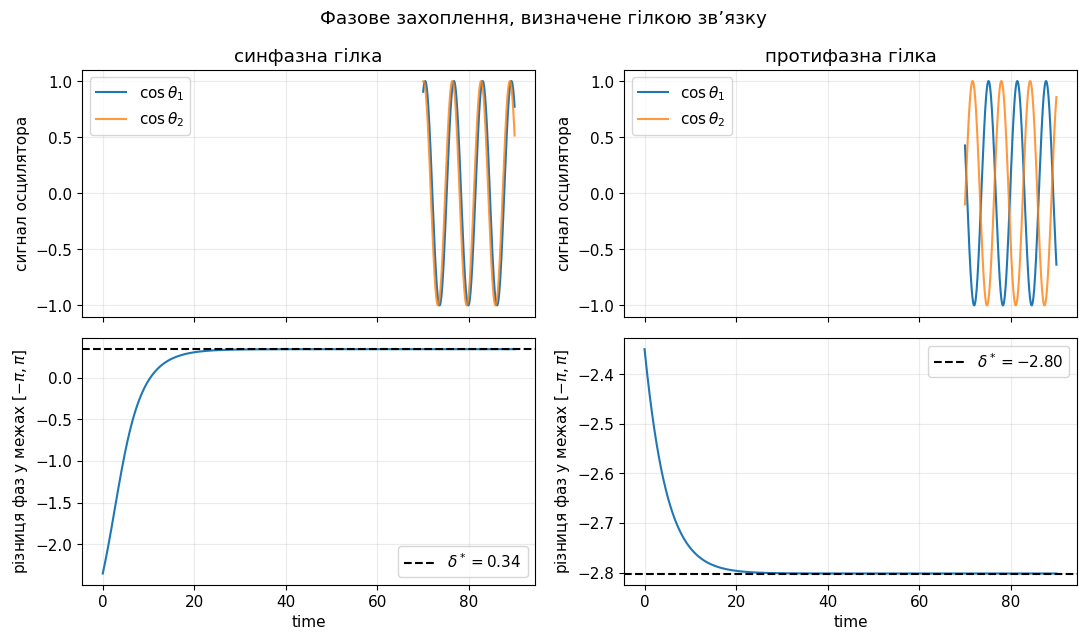

In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = np.random.default_rng(20260904)

def phase_locked_pair(delta0, delta_omega=0.08, K=0.12,
                      omega_mean=1.0, dt=0.02, duration=90.0):
    # Фазова модель пари автоколивних осциляторів у наближенні слабкого зв'язку.
    t = np.arange(0.0, duration + dt, dt)
    theta = np.empty((2, t.size))
    theta[:, 0] = (0.0, -2.35)
    omega = np.array([omega_mean - delta_omega/2,
                      omega_mean + delta_omega/2])
    for n in range(t.size - 1):
        delta = theta[1, n] - theta[0, n]
        interaction = K*np.sin(delta - delta0)
        theta[:, n + 1] = theta[:, n] + dt*np.array([
            omega[0] + interaction,
            omega[1] - interaction,
        ])
    wrapped_delta = np.angle(np.exp(1j*(theta[1] - theta[0])))
    return t, theta, wrapped_delta

cases = [(0.0, "синфазна гілка"), (np.pi, "протифазна гілка")]
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex="col")
for col, (delta0, label) in enumerate(cases):
    t, theta, delta = phase_locked_pair(delta0)
    tail = t > 70
    axes[0, col].plot(t[tail], np.cos(theta[0, tail]), label=r"$\cos\theta_1$")
    axes[0, col].plot(t[tail], np.cos(theta[1, tail]), label=r"$\cos\theta_2$", alpha=0.8)
    axes[0, col].set_title(label)
    axes[0, col].set_ylabel("сигнал осцилятора")
    axes[0, col].legend()
    target = np.angle(np.exp(1j*(delta0 + np.arcsin(0.08/(2*0.12)))))
    axes[1, col].plot(t, delta)
    axes[1, col].axhline(target, color="k", ls="--", label=fr"$\delta^*={target:.2f}$")
    axes[1, col].set(xlabel="time", ylabel="різниця фаз у межах $[-π,π]$")
    axes[1, col].legend()
plt.suptitle("Фазове захоплення, визначене гілкою зв’язку")
plt.tight_layout()
plt.show()


## Консервативні маятники та автоколивні метрономи: зв'язок ще не означає захоплення

Годинник Гюйгенса — це маятник зі спусковим механізмом, який компенсує втрати енергії. Тому істотна відмінність проходить між **консервативними коливаннями** та **автоколиваннями з підведенням і дисипацією енергії**, а не між формою маятника й метронома. Нижче порівнюємо ту саму механічну геометрію та однакові початкові умови, змінюючи лише внутрішній момент сили.

Два однакові точкові маятники маси $m$ і довжини $L$ підвішено до жорсткої горизонтальної балки маси $M$. Балка поступально рухається без тертя; її вертикальний рух і обертання заборонені ідеальними в'язями, що не виконують роботи. Усі розміри далі безрозмірні: $\tau=t\sqrt{g/L}$, $x=X/L$, $R=M/m$. Тут система консервативна за відсутності внутрішніх моментів; це не повністю ізольована конструкція у вільному падінні. Фіксуємо **горизонтальний центр мас** та нульовий горизонтальний імпульс:

$$x=-\frac{\sin\theta_1+\sin\theta_2}{R+2}.$$

Після виключення координати балки рівняння мають вигляд

$$\sum_{j=1}^{2}\left[\delta_{ij}-\frac{\cos\theta_i\cos\theta_j}{R+2}\right]\theta_j''=-\sin\theta_i-\frac{\cos\theta_i}{R+2}\sum_{j=1}^{2}\sin\theta_j(\theta_j')^2+q_i.$$

У консервативному випадку $q_i=0$. Для спрощеного аналога спускового механізму використано момент ван дер Поля $q_i=\mu[1-(\theta_i/a)^2]\theta_i'$: він підводить енергію за малих амплітуд та відбирає її за великих. Це модель автоколивного маятника, а не точна модель конкретного метронома. В обох випадках геометрія, маси та початкові умови однакові.

Консервативна енергія в одиницях $mgL$ дорівнює

$$\mathcal E=\frac12\left[(\theta_1')^2+(\theta_2')^2-\frac{(\cos\theta_1\theta_1'+\cos\theta_2\theta_2')^2}{R+2}\right]+2-\cos\theta_1-\cos\theta_2.$$

За $q_i=0$ вона зберігається; за наявності моментів $\mathcal E'=\sum_i q_i\theta_i'$. Малокутові нормальні моди мають частоти $\Omega_{\mathrm{anti}}=1$ і $\Omega_{\mathrm{in}}=\sqrt{1+2/R}$. Синфазна мода супроводжується віддачею балки, протифазна — взаємною компенсацією сил та нерухомою балкою. Суміш мод дає биття; важча балка зменшує розщеплення частот. Точно симетричні початкові умови задають синхронні рухи, проте вони **не є атракторами** консервативної системи. У нелінійному консервативному випадку також можливі області обмеженої відносної фази; сама фазова узгодженість ще не доводить притягання.

Для наочного порівняння нижче використано $\phi_i=\operatorname{atan2}(-\theta_i',\theta_i)$ та $\Delta\phi=\arccos[\cos(\phi_1-\phi_2)]$. Це геометрична діагностика для малих коливань, а не строгий ізохронний фазовий опис. Біля нульової амплітуди фаза погано визначена. Значення $0^\circ$ означає рух разом, $180^\circ$ — у протилежних фазах. Ознакою захоплення в автоколивній системі є зближення фазової поведінки з різних початкових умов після перехідного процесу; окрема синхронна траєкторія цього не доводить.


In [24]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display


def huygens_rhs(y, R, driven=False, mu=0.15, a=0.15):
    """Безрозмірна механіка; координату балки виключено через імпульс."""
    p, q, u, v = y
    c, d = math.cos(p), math.cos(q)
    sp, sq = math.sin(p), math.sin(q)
    S = (sp*u*u + sq*v*v)/(R+2)
    b1, b2 = -sp-c*S, -sq-d*S
    if driven:
        b1 += mu*(1-(p/a)**2)*u
        b2 += mu*(1-(q/a)**2)*v
    A, B, D = 1-c*c/(R+2), -c*d/(R+2), 1-d*d/(R+2)
    determinant = A*D-B*B
    return (u, v, (D*b1-B*b2)/determinant,
            (A*b2-B*b1)/determinant)


def huygens_integrate(R=10.0, initial="mixed", driven=False,
                      duration=600.0, dt=0.01):
    """RK4; збереження енергії перевіряється окремо, не нав'язується."""
    if not np.isfinite(R) or R <= 0 or dt <= 0 or duration <= 0:
        raise ValueError("Потрібні R > 0, dt > 0 та duration > 0.")
    presets = {"in": (.22, .22, 0., 0.),
               "anti": (.22, -.22, 0., 0.),
               "mixed": (.22, -.08, 0., .65)}
    y = presets[initial]
    steps = int(round(duration/dt))
    stride = max(1, int(round(.05/dt)))
    times, states = [], []
    for n in range(steps+1):
        if n % stride == 0 or n == steps:
            times.append(n*dt)
            states.append(y)
        if n == steps:
            break
        k1 = huygens_rhs(y, R, driven)
        k2 = huygens_rhs(tuple(z+dt*k/2 for z, k in zip(y, k1)), R, driven)
        k3 = huygens_rhs(tuple(z+dt*k/2 for z, k in zip(y, k2)), R, driven)
        k4 = huygens_rhs(tuple(z+dt*k for z, k in zip(y, k3)), R, driven)
        y = tuple(z+dt*(b+2*c+2*d+e)/6
                  for z, b, c, d, e in zip(y, k1, k2, k3, k4))
    t, y = np.asarray(times), np.asarray(states)
    angles, velocities = y[:, :2], y[:, 2:]
    cosine = np.cos(angles)
    x = -np.sin(angles).sum(axis=1)/(R+2)
    xdot = -(cosine*velocities).sum(axis=1)/(R+2)
    energy = .5*(np.sum(velocities**2, axis=1)
                 - np.sum(cosine*velocities, axis=1)**2/(R+2))
    energy += np.sum(1-np.cos(angles), axis=1)
    phi = np.arctan2(-velocities, angles)
    phase_gap = np.degrees(np.arccos(np.clip(np.cos(phi[:, 0]-phi[:, 1]), -1, 1)))
    return dict(t=t, y=y, x=x, xdot=xdot, energy=energy, phase_gap=phase_gap,
                R=R, driven=driven)


def huygens_comparison(R=10.0, initial="mixed", duration=600.0):
    cases = [huygens_integrate(R, initial, driven, duration)
             for driven in (False, True)]
    fig, axes = plt.subplots(3, 2, figsize=(12, 9), constrained_layout=True)
    names = ["Консервативні маятники", "Автоколивні маятники"]
    for col, (result, name) in enumerate(zip(cases, names)):
        t, y = result["t"], result["y"]
        for j, style in enumerate(("-", "--")):
            axes[0, col].plot(t, y[:, j], style, label=f"Маятник {j+1}")
        axes[0, col].set(xlim=(0, 100), ylabel="Кут (рад)", title=name)
        axes[0, col].legend()
        axes[1, col].plot(t, result["phase_gap"])
        axes[1, col].set(ylim=(-5, 185), yticks=[0, 90, 180],
                         ylabel="Різниця фаз (град)")
        axes[2, col].plot(t, result["energy"]/result["energy"][0])
        axes[2, col].set(ylabel="Енергія / початкова енергія", ylim=(0, 1.2))
        for row in range(3):
            axes[row, col].set_xlabel(r"Час $\tau=t\sqrt{g/L}$")
    fig.suptitle(f"Однакові початкові умови; M/m = {R:g}")
    plt.show()
    error = np.max(np.abs(cases[0]["energy"]/cases[0]["energy"][0]-1))
    print(f"Максимальна відносна похибка консервативної енергії: {error:.2e}")
    return cases


def huygens_animation(cases, start=0.0, window=50.0):
    """Синхронний перегляд двох моделей у горизонтальній системі центра мас."""
    last_time = min(case["t"][-1] for case in cases)
    start = float(np.clip(start, 0, max(0, last_time-window)))
    frames = np.arange(start, min(start+window, last_time), .1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
    artists = []
    for ax, name in zip(axes, ("Консервативні", "Автоколивні")):
        ax.set(xlim=(-1.8, 1.8), ylim=(-1.3, .4), aspect="equal", title=name,
               xlabel="x / L", ylabel="y / L")
        ax.axvline(0, color="0.6", linestyle=":", label="Горизонтальний ЦМ")
        bar, = ax.plot([], [], color="0.4", lw=5)
        rods = [ax.plot([], [], style, lw=2)[0] for style in ("-", "--")]
        bobs = [ax.plot([], [], "o", color=rod.get_color(), ms=9)[0] for rod in rods]
        text = ax.text(.02, .92, "", transform=ax.transAxes)
        artists.append((bar, rods, bobs, text))

    def update(tau):
        updated = []
        for case, (bar, rods, bobs, text) in zip(cases, artists):
            # Linear interpolation of the saved states keeps playback smooth.
            state = [np.interp(tau, case["t"], case["y"][:, j]) for j in range(4)]
            x = -(math.sin(state[0])+math.sin(state[1]))/(case["R"]+2)
            bar.set_data([x-1.25, x+1.25], [0, 0])
            for j in range(2):
                pivot = x+(-.65 if j == 0 else .65)
                bx, by = pivot+math.sin(state[j]), -math.cos(state[j])
                rods[j].set_data([pivot, bx], [0, by])
                bobs[j].set_data([bx], [by])
            text.set_text(f"τ = {tau:.1f}")
            updated.extend([bar, *rods, *bobs, text])
        return updated

    animation = FuncAnimation(fig, update, frames=frames, interval=200,
                              blit=False, repeat=False)
    html = HTML(animation.to_jshtml(default_mode="once"))
    plt.close(fig)
    return html


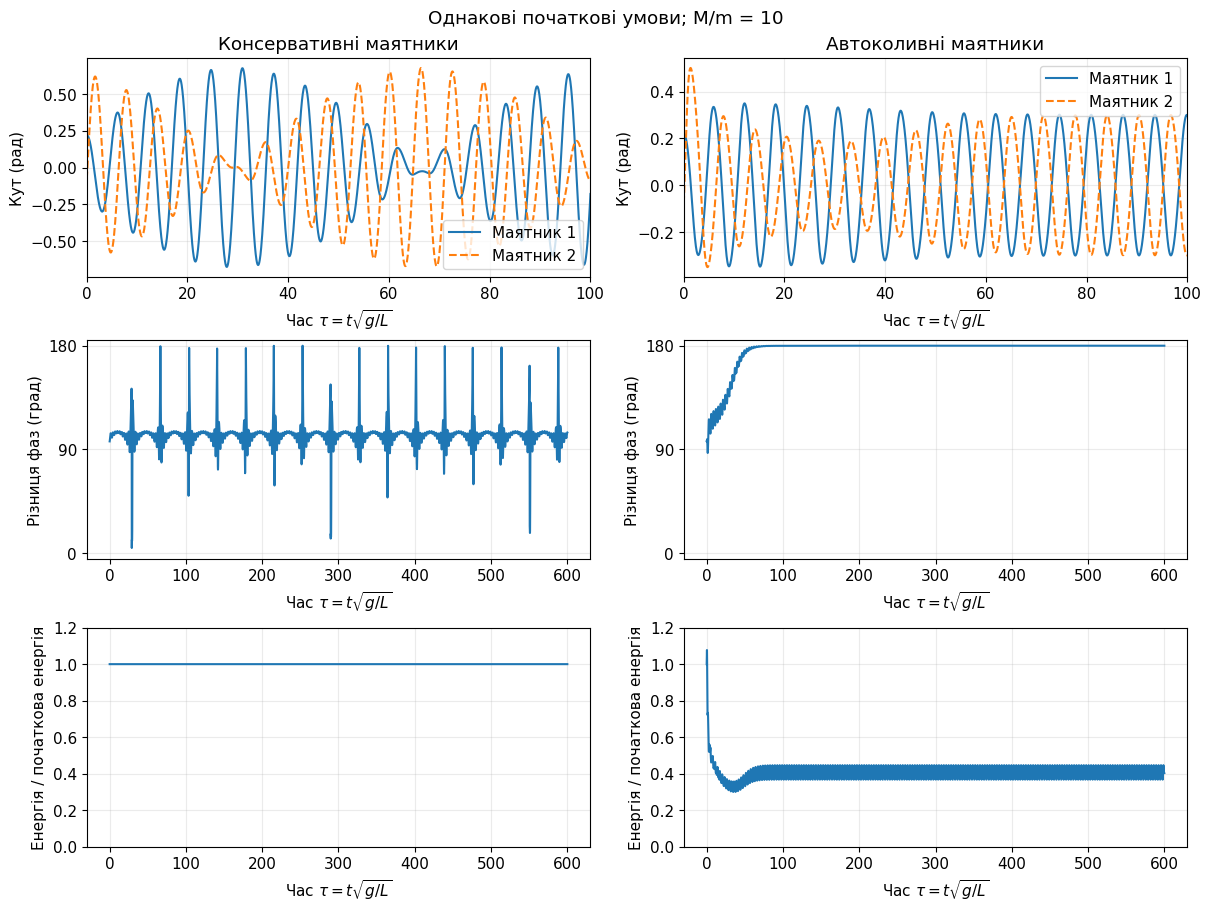

Максимальна відносна похибка консервативної енергії: 9.54e-10


In [25]:
# Змініть M_over_m: 1, 10, 100, 1000; initial: mixed, in, anti.
M_over_m = 10.0
initial = "mixed"
pendulum_cases = huygens_comparison(M_over_m, initial)


### Анімація та інтерпретація

Змініть `start` з `0` на `500`, щоб порівняти початковий і пізній рух. Обидві моделі показано одночасно. Консервативна механічна енергія зберігається; автоколивний момент забезпечує обмін енергією з приводом. За `M_over_m=10` та `initial="mixed"` ця автоколивна модель прямує до протифазного руху; це не універсальна поведінка метрономів. Повторіть обчислення з кількома близькими неоднаковими початковими станами, змінивши набір `mixed`. Порівняйте пізню варіацію фаз, щоб відрізнити атрактор від биття або спеціально підготовленої синхронної траєкторії.


In [19]:
display(huygens_animation(pendulum_cases, start=0.0))


## Параметр порядку Курамото

Модель глобально зв'язаних фаз має вигляд

$$\dot\theta_i=\omega_i+\frac{K}{N}\sum_j\sin(\theta_j-\theta_i).$$

Визначимо $Z=re^{i\psi}=N^{-1}\sum_j e^{i\theta_j}$. Тоді

$$\dot\theta_i=\omega_i+Kr\sin(\psi-\theta_i).$$

Взаємодію багатьох тіл закодовано колективним полем $Z$. Це особливо прозорий приклад циклічної причинності: фази породжують параметр порядку, а він у відповідь діє на кожну фазу. Для симетричного одновершинного розподілу власних частот $g$ поріг нескінченної системи дорівнює $K_c=2/[\pi g(0)]$.


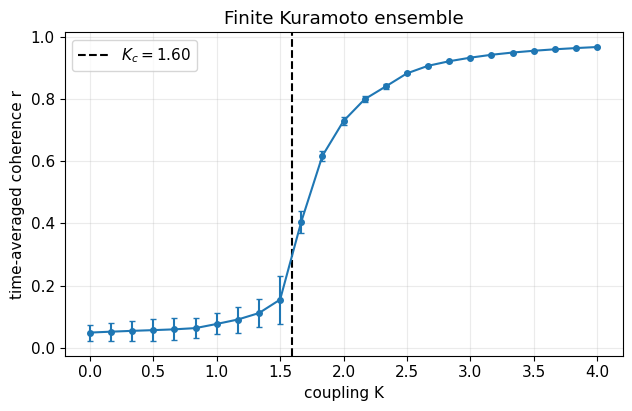

In [10]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = np.random.default_rng(20260904)

def kuramoto(K, omega, theta0, dt=0.03, steps=3500, burn=1500):
    theta = theta0.copy()
    r_history = []
    for n in range(steps):
        Z = np.mean(np.exp(1j*theta))
        theta += dt*(omega + K*np.abs(Z)*np.sin(np.angle(Z)-theta))
        if n >= burn:
            r_history.append(abs(np.mean(np.exp(1j*theta))))
    return np.mean(r_history), np.std(r_history), theta

N = 400
omega = rng.normal(0, 1, N)
theta0 = rng.uniform(0, 2*np.pi, N)
K_values = np.linspace(0, 4, 25)
stats = np.array([kuramoto(K, omega, theta0)[:2] for K in K_values])
Kc_theory = 2/(np.pi*(1/np.sqrt(2*np.pi)))

plt.errorbar(K_values, stats[:, 0], yerr=stats[:, 1], marker="o", ms=4, capsize=2)
plt.axvline(Kc_theory, color="k", ls="--", label=fr"$K_c={Kc_theory:.2f}$")
plt.xlabel("coupling K")
plt.ylabel("time-averaged coherence r")
plt.title("Finite Kuramoto ensemble")
plt.legend()
plt.show()


## Оцінюване завдання

**Частина A.** Проскануйте розстройку $\Delta\omega$ та силу зв'язку $K$ у фазовій моделі годинників/метрономів. Класифікуйте захоплення за довгочасовим дрейфом $\delta$, побудуйте межу області захоплення й порівняйте її з $|\Delta\omega|=2K$. Поясніть, чому лише з цього розрахунку не можна встановити, синфазний чи протифазний стан обере реальна опора.

**Частина B.** Повторіть сканування Курамото для $N=100,400,1600$, щоразу використовуючи незалежні вибірки власних частот. Оцініть скінченно-розмірний фоновий рівень когерентності нижче порога, задайте операційне визначення $K_c(N)$ і обережно екстраполюйте його до теоретичного значення.

Подання має містити чітке твердження, його математичне або фізичне обґрунтування, числові свідчення та принаймні одне обмеження висновку.


## Література та атрибуція

**Основне читання з локальної бібліотеки:** Kuramoto, *Chemical Oscillations, Waves, and Turbulence*; Mikhailov, *Foundations of Synergetics I*, розділи про коливальні середовища. Механічні виведення та експерименти подано також в авторському архіві `metronome.nb`, `metronome0.nb`, `Two Metronomes.nb`, `synchro1.mp4` і `synchro2.mp4`.

**Перевірені вебджерела:**
- [Physics World: The secret of the synchronized pendulums](https://physicsworld.com/a/the-secret-of-the-synchronized-pendulums/)
- [Pantaleone: Synchronization of metronomes](https://doi.org/10.1119/1.1501118)
- [Bennett et al.: Huygens's clocks](https://doi.org/10.1098/rspa.2001.0888)
- [Oliveira and Melo: Huygens synchronization of two clocks](https://doi.org/10.1038/srep11548)
- [Kuramoto, Chemical Oscillations, Waves, and Turbulence](https://doi.org/10.1007/978-3-642-69689-3)

Локальні книги є наданими матеріалами курсу. Вебпосилання мають додатковий характер; їх перевірено 08.09.2026.
